# Full-data business entity resolution

**Pipeline:** full TSV inputs → preserved text + entity-family split → overlapping candidate buckets → pair features → LightGBM matcher → threshold selected with macro F0.5 → full test predictions → strict and official format validation → visual inspection.

This notebook uses `student_resource/dataset/train` and `test`, **not sampled files**. Every S1 is processed in its assigned fold or in test. Up to eight mined negatives per fitting query control pair volume; all fitting positives and all evaluation candidates are retained. Batching is a memory technique, not a query sample.

The existing `train.ipynb` is preserved. Production code is in `src/er/full_*.py`; each section links its implementation explanation in `docs/notebook/`. Test outputs have no known labels: charts cannot establish test accuracy. First place is not guaranteed.

Select the project `.venv/bin/python` kernel. Run in order. Long stages stop at resource budgets with checkpoints; rerun the same cell to resume. A stopped model fit restarts. Unexecuted cells have no measured results. See [execution status](docs/notebook/09_execution_status.md).

## 1. Environment and full-data paths
[Step documentation](docs/notebook/01_environment.md). Dependencies are pinned in `requirements-notebook.txt`. Install into this project's environment if needed: `.venv/bin/pip install -r requirements-notebook.txt`. Installation is deliberately not hidden inside a notebook cell.

In [ ]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().resolve()
if not (ROOT / "student_resource").is_dir() and (ROOT.parent / "student_resource").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "student_resource/dataset/train/train_source1.tsv").exists(), "Open from the project root"
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "artifacts/matplotlib_cache"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.er.full_notebook import (run_stage, data_figures, pair_feature_figures,
                                  feature_figures, evaluation_figures, test_figures)
from src.er.full_features import FEATURES, views
from src.er.full_store import connect, getmeta, Blocker
CONFIG = ROOT / "configs/full_notebook.json"
cfg = json.loads(CONFIG.read_text())
assert Path(cfg["project_root"]).resolve() == ROOT, "Update project_root in config after moving this project"
RUN = ROOT / cfg["run_dir"]
FIGURES = RUN / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
display(pd.Series(cfg, name="Full-data configuration").to_frame())
print("Kernel:", sys.executable)
print("Feature count:", len(FEATURES))

,Full-data configuration
project_root,/home/srmist/Desktop/Amazon_ML
data_dir,student_resource/dataset
run_dir,artifacts/full_notebook_v1
seed,42
batch_queries,1000
per_source_cap,50
per_route_k,30
max_postings,20000
negative_per_query,8
threads,4


Kernel: /home/srmist/Desktop/Amazon_ML/.venv/bin/python
Feature count: 34


## 2. Ingest all records, verify truth, create family splits
[Step documentation](docs/notebook/02_data_and_splits.md). Approximately 80% of positive components fit the model, 10% tune the decision and 10% remain a final holdout. Shared targets cannot cross folds. Missing truth rows are errors, not singleton labels.

Both source corpora are streamed to disk. Each completed stage records full counts and checksums. Rerunning safely reuses completed imports; changed inputs fail.

In [3]:
train_ingestion = run_stage(CONFIG, "ingest-train")

train source3: 5,000,000 rows
Completed ingest-train: 2.0s, peak RSS 0.00 GiB


In [4]:
test_ingestion = run_stage(CONFIG, "ingest-test")

test source3: 5,000,000 rows
Completed ingest-test: 2.0s, peak RSS 0.00 GiB


Completed profile: 18.0s, peak RSS 0.43 GiB


,source,country,n,blank_name,blank_address,split
0,1,India,883188,0,0,train
1,1,US,1323633,0,0,train
2,2,India,2017799,0,57846,train
3,2,US,3016817,0,111121,train
4,3,India,2115547,0,64948,train
5,3,US,3170056,0,110968,train
6,1,France,259452,0,0,test
7,1,India,809986,0,0,test
8,1,US,663106,0,0,test
9,2,France,703378,0,21537,test


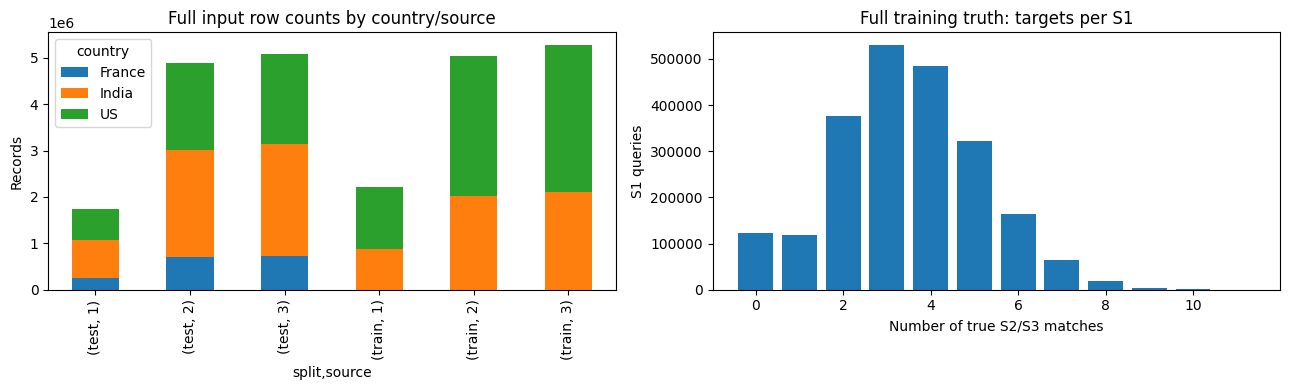

,S1 queries by family fold
fit,1764550
holdout,221036
tune,221235


In [5]:
run_stage(CONFIG, "profile")
full_counts, fig = data_figures(RUN)
display(full_counts)
fig.savefig(FIGURES / "01_full_data_profile.png", dpi=150, bbox_inches="tight")
plt.show()
with connect(RUN / "train.sqlite") as c:
    display(pd.Series(getmeta(c, "splits")["counts"], name="S1 queries by family fold").to_frame())

## 3. Build overlapping buckets over the full target pool
[Step documentation](docs/notebook/03_blocking.md). Native/transliterated name tokens, address tokens, initials aliases, and name four-grams retrieve independently. The union is ranked and capped separately for S2 and S3. Every target remains eligible in its routed partition.

Buckets contain lookalikes; they are not identity clusters. No equality requirement on city/state/house number, no forced top-1 decision and no automatic transitive merging. Known-country routing assumes country consistency; unknown/new countries have a fallback. Rare-term and candidate caps can miss positives, which validation must count.

In [6]:
train_index = run_stage(CONFIG, "index-train")

indexed through record 2,306,821
indexed through record 2,406,821
indexed through record 2,506,821
indexed through record 2,606,821
indexed through record 2,706,821
indexed through record 2,806,821
indexed through record 2,906,821
indexed through record 3,006,821
indexed through record 3,106,821
indexed through record 3,206,821
indexed through record 3,306,821
indexed through record 3,406,821
indexed through record 3,506,821
indexed through record 3,606,821
indexed through record 3,706,821
indexed through record 3,806,821
indexed through record 3,906,821
indexed through record 4,006,821
indexed through record 4,106,821
indexed through record 4,206,821
indexed through record 4,306,821
indexed through record 4,406,821
indexed through record 4,506,821
indexed through record 4,606,821
indexed through record 4,706,821
indexed through record 4,806,821
indexed through record 4,906,821
indexed through record 5,006,821
indexed through record 5,106,821
indexed through record 5,206,821
indexed th

The following optional inspection displays one real query's natural bucket. It does not restrict the full processing cells. This is a debugging view, not a measured recall result.

In [7]:
b = Blocker(RUN / "train.sqlite", cfg["per_source_cap"], cfg["per_route_k"], cfg["max_postings"])
try:
    query = dict(b.c.execute("SELECT * FROM records WHERE source=1 ORDER BY rid LIMIT 1").fetchone())
    bucket = b.retrieve(query)
    display(pd.DataFrame([query]))
    display(pd.DataFrame([dict(entity_id=h["record"]["entity_id"],
                               name=h["record"]["name"], address=h["record"]["address"],
                               country=h["record"]["country"], routes=",".join(h["routes"]),
                               rank_fusion=h["fusion"]) for h in bucket]))
finally:
    b.close()

,rid,entity_id,source,name,address,country
0,1,S1-925783039,1,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US


,entity_id,name,address,country,routes,rank_fusion
0,S2-415733261,Sweet Barbershop (Co),"05131 COPPER MEADOW LN, WEST JORDAN CITY, UT",US,"name,grams",0.032787
1,S2-838401167,English's Barbershop Group,"814 JJ, BANCROT CDP, WI",US,"name,grams",0.031281
2,S2-518413297,Cozy Barbershop Inc,"92 34ST STREET, KANSAS CITY, MO",US,"name,grams",0.030579
3,S2-748268413,BARBERSHOP URBAN (WEST),"00783 25, RICHFIELD, NY",US,"name,grams",0.030118
4,S2-878352124,Lucky Barbershop,"9004 DANTE AVE, CHICAGO, IL",US,"name,grams",0.029670
...,...,...,...,...,...,...
95,S3-201681800,Cooperative Wireless Services Inc,"634 Fairfield St, Ohio, Wraren",US,grams,0.012821
96,S3-103827788,Fluxjax aka Hudson Cardiology,"94 High Street, Unit 1, Ipswich, MA",US,address,0.012821
97,S3-558325632,Little Barbershop Ltd.,"588 300, American Fork, Utah",US,name,0.012821
98,S3-998710415,Jacobs Integrated Pro Harbor,"321 High Rock Road, New Baltimore, New York",US,address,0.012658


## 4. Generate noise-aware features and supervised pairs
[Step documentation](docs/notebook/04_features.md). Native and transliterated similarities, token order/set agreement, duplication, acronym evidence, address normalization, numeric conflict, length ratios, missingness and script change form 34 features. Neither IDs nor country-category one-hot columns are predictors.

**Full query pass:** every fitting query supplies all positives plus up to eight retrieved eligible hard negatives. Held-out-family targets are excluded from fitting negatives. Missed fitting positives are explicitly tagged injections; they never enter tuning/holdout buckets by fiat. Evaluation keeps every natural candidate and the complete true-match count. All folds are materialized, but final-holdout results stay sealed.

In [ ]:
display(pd.DataFrame({"feature_index": range(len(FEATURES)), "feature": FEATURES}))
pair_materialization = run_stage(CONFIG, "pairs")

,feature_index,feature
0,0,name_ratio
1,1,name_token_sort
2,2,name_token_set
3,3,latin_name_ratio
4,4,latin_name_token_sort
5,5,latin_name_token_set
6,6,core_ratio
7,7,core_token_set
8,8,address_ratio
9,9,address_token_sort


fit: completed queries through 41,473; 11,520 pairs in shard
fit: completed queries through 37,717; 11,506 pairs in shard
fit: completed queries through 33,993; 11,433 pairs in shard
fit: completed queries through 38,976; 11,456 pairs in shard
fit: completed queries through 40,211; 11,486 pairs in shard
fit: completed queries through 44,001; 11,393 pairs in shard
fit: completed queries through 49,008; 11,406 pairs in shard
fit: completed queries through 46,496; 11,452 pairs in shard
fit: completed queries through 51,516; 11,500 pairs in shard
fit: completed queries through 52,755; 11,365 pairs in shard
fit: completed queries through 53,998; 11,382 pairs in shard
fit: completed queries through 56,502; 11,454 pairs in shard
fit: completed queries through 55,269; 11,463 pairs in shard
fit: completed queries through 62,673; 11,486 pairs in shard
fit: completed queries through 60,200; 11,420 pairs in shard
fit: completed queries through 61,429; 11,413 pairs in shard


In [ ]:
fig = pair_feature_figures(RUN)
fig.savefig(FIGURES / "02_full_fit_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Train the matching model
[Step documentation](docs/notebook/05_model.md). LightGBM learns from the fitting fold's real labels. A matching name with a conflicting address is evidence to weigh, not an automatically positive or negative rule. Query weights balance families with different pair counts.

Raw arrays are memory mapped; LightGBM's binned dataset still consumes RAM. The watchdog checks the actual process. The saved model and feature order are versioned. This CPU baseline uses no external business lookup or pretrained checkpoint.

In [ ]:
model_training = run_stage(CONFIG, "train")
display(pd.Series(json.loads((RUN / "model_card.json").read_text())).to_frame("Model card"))

In [ ]:
importance, fig = feature_figures(RUN)
fig.savefig(FIGURES / "03_model_feature_gain.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Tune acceptance using the exact competition metric
[Step documentation](docs/notebook/06_evaluation.md).

For nonempty truth, each query scores `1.25*TP / (1.25*TP + 0.25*FN + FP)`. True singletons score 1 only for no prediction. Macro-average all queries; missing candidates remain false negatives.

Tune a global threshold on complete natural tuning shortlists. The oracle accepts exactly retrieved positives and is only a ceiling. Report retrieval recall and singleton errors alongside model score. No threshold is learned from unlabelled French test records.

In [ ]:
tuning = run_stage(CONFIG, "tune")
tune_report = json.loads((RUN / "tune_metrics.json").read_text())
display(pd.Series({k:v for k,v in tune_report.items() if not isinstance(v, (list, dict))}).to_frame("Tuning measurement"))
slices, fig = evaluation_figures(RUN, "tune")
display(slices)
fig.savefig(FIGURES / "04_tuning_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
display(pd.DataFrame(tune_report["error_examples"]))

NameError: name 'run_stage' is not defined

### Freeze, then open the final holdout
Execute this cell only after deciding this is the final policy for this experiment. Executing it opens the protected holdout and records that event. Do not alter the model or threshold in response to its result and continue calling it untouched. A new run directory does not erase knowledge of the same holdout.

The model used for test remains the same fitting-fold model; no unreported all-label refit occurs.

In [ ]:
final_evaluation = run_stage(CONFIG, "holdout")
final_report = json.loads((RUN / "holdout_metrics.json").read_text())
display(pd.Series({k:v for k,v in final_report.items() if not isinstance(v, (list, dict))}).to_frame("Final holdout measurement"))

## 7. Predict every test S1 and validate outputs
[Step documentation](docs/notebook/07_prediction_validation.md). Build full S2/S3 test indexes, score all retained pairs, and accept zero or more targets. Completed shards are restartable; final TSVs publish only after full query coverage.

Expected output names and columns:
- `matching_results.tsv`: `source1_entity_id`, `matched_entity_ids`
- `candidate_pairs.tsv`: `source1_entity_id`, `candidate_entity_ids`

Every S1 appears once, including predicted singletons. Matches must belong to the exact exported candidate bucket.

In [ ]:
test_index = run_stage(CONFIG, "index-test")

In [ ]:
test_inference = run_stage(CONFIG, "predict")
print("Matching output:", RUN / "output/matching_results.tsv")
print("Candidate output:", RUN / "output/candidate_pairs.tsv")

Strict full-output validation checks IDs, coverage, duplicate rows/targets, schemas and candidate subsets. The supplied `student_resource/utils/validate_submission.py` is then run unchanged with `--check-ids` on **every corresponding shard** to keep its in-memory dictionaries bounded. All test queries are covered. Logs distinguish this from a monolithic official invocation. No upload is performed.

In [ ]:
submission_validation = run_stage(CONFIG, "validate")
display(pd.Series(json.loads((RUN / "validation.json").read_text())).to_frame("Validation evidence"))

## 8. Visualize the full test predictions
[Step documentation](docs/notebook/08_visualizations.md). The aggregate plots cover every test prediction. The bounded inspection table displays raw text, model scores, decisions and retrieval routes.

**Unlabelled test:** neither high scores nor visually plausible pairs establish correctness. Test accuracy/F0.5 cannot be computed without truth.

In [ ]:
country_predictions, inspection, fig = test_figures(RUN)
display(country_predictions)
fig.savefig(FIGURES / "05_full_test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
display(inspection)
inspection.to_csv(RUN / "test_prediction_inspection.tsv", sep="\t", index=False)

## Completion evidence and next experiments
A successful run has `model.txt`, `decision.json`, tuning/final reports, full output TSVs, `validation.json`, saved figures, and stage logs. Without those files, the corresponding task is incomplete; do not quote a fabricated model or test score.

Improve the largest measured loss first: retrieval misses → extra/expanded retrieval routes; false merges → hard negatives/conflict features; rejection of retrieved truth → features/calibration. Use controlled ablations on tuning data and preserve the already-opened holdout history. Multilingual embeddings, train-only fine-tuning, country-transfer stress tests and calibrated ensembles are possible follow-up experiments, not implemented claims here.